In [1]:
import yfinance as yf
from nsepy import get_history
import datetime
import pandas as pd

# File name
file_name = "DMART_data.csv"

# Try Yahoo Finance first
try:
    print("Trying Yahoo Finance...")
    ticker = "DMART.NS"
    data = yf.download(ticker, start="2023-04-01", end="2025-09-01", progress=False)

    # Check if data is empty
    if data.empty:
        raise Exception("Yahoo returned empty data.")

    print("Yahoo Finance download successful ✅")

except Exception as e:
    print(f"Yahoo Finance failed: {e}")
    print("Switching to NSEpy...")

    # Use NSEpy if Yahoo fails
    data = get_history(
        symbol="DMART",
        start=datetime.date(2023,4,1),
        end=datetime.date(2025,9,1)
    )
    print("NSEpy download successful ✅")

# Save to CSV
data.to_csv(file_name)
print(f"Data saved as {file_name}")


Trying Yahoo Finance...


C:\Users\Maryam\AppData\Local\Temp\ipykernel_15536\2629067791.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2023-04-01", end="2025-09-01", progress=False)


Yahoo Finance download successful ✅
Data saved as DMART_data.csv


In [2]:
import yfinance as yf
import pandas as pd

# NIFTY 50 ticker on Yahoo Finance
ticker = "^NSEI"

# Download data
nifty_data = yf.download(ticker, start="2023-04-01", end="2025-09-01")

# Save to CSV
nifty_data.to_csv("NIFTY50_data.csv")

print("NIFTY 50 data downloaded and saved as NIFTY50_data.csv")
print(nifty_data.head())


C:\Users\Maryam\AppData\Local\Temp\ipykernel_15536\2807536158.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty_data = yf.download(ticker, start="2023-04-01", end="2025-09-01")
[*********************100%***********************]  1 of 1 completed

NIFTY 50 data downloaded and saved as NIFTY50_data.csv
Price              Close          High           Low          Open  Volume
Ticker             ^NSEI         ^NSEI         ^NSEI         ^NSEI   ^NSEI
Date                                                                      
2023-04-03  17398.050781  17428.050781  17312.750000  17427.949219  230200
2023-04-05  17557.050781  17570.550781  17402.699219  17422.300781  248300
2023-04-06  17599.150391  17638.699219  17502.849609  17533.849609  242700
2023-04-10  17624.050781  17694.099609  17597.949219  17634.900391  254800
2023-04-11  17722.300781  17748.750000  17655.150391  17704.800781  304300


In [3]:
import pandas as pd

dmart = pd.read_csv("DMART_data.csv")
nifty = pd.read_csv("NIFTY50_data.csv")

print("DMart columns:", dmart.columns)
print("NIFTY columns:", nifty.columns)


DMart columns: Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
NIFTY columns: Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [4]:
# =====================================
# STEP 1: IMPORT LIBRARIES & LOAD DATA
# =====================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from hmmlearn.hmm import GaussianHMM

plt.style.use("seaborn-v0_8-darkgrid")  # dark aesthetic

# Load CSV's
# DMart
dmart = pd.read_csv(r"C:\Users\Maryam\MSc\Field Project\DMART_data.csv")
dmart['Date'] = pd.to_datetime(dmart['Date'], dayfirst=True)
dmart.set_index('Date', inplace=True)

# NIFTY
nifty = pd.read_csv(r"C:\Users\Maryam\MSc\Field Project\NIFTY50_data.csv")
nifty['Date'] = pd.to_datetime(nifty['Date'], dayfirst=True)
nifty.set_index('Date', inplace=True)

# Merge both
data = pd.DataFrame({
    'DMart_Close': dmart['Close'],
    'Nifty_Close': nifty['Close']
}).dropna()

data.head()

# Drop rows where Close is NaN (conversion failed)
dmart = dmart.dropna(subset=['Close'])

# Now calculate daily returns
dmart['Daily_Return'] = dmart['Close'].pct_change()
nifty['Daily_Return'] = nifty['Close'].pct_change()

# Drop the first NaN created by pct_change
dmart_clean = dmart.dropna(subset=['Daily_Return']).copy()
nifty_clean = nifty.dropna(subset=['Daily_Return']).copy()

print(nifty.info())
print(dmart.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 594 entries, 2023-04-03 to 2025-08-29
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         594 non-null    float64
 1   High          594 non-null    float64
 2   Low           594 non-null    float64
 3   Open          594 non-null    float64
 4   Volume        594 non-null    int64  
 5   Daily_Return  593 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 48.6 KB
None
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 595 entries, 2023-04-03 to 2025-08-29
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         595 non-null    float64
 1   High          595 non-null    float64
 2   Low           595 non-null    float64
 3   Open          595 non-null    float64
 4   Volume        595 non-null    int64  
 5   Daily_Return  594 non-null    float64
dtypes: fl

### 📌 Introduction & Objectives
###### - Is the stock risky or safe? (Volatility + Beta vs NIFTY)
###### - Best time to invest/exit? (trends, moving averages)
###### - Is company in profit/loss? (fundamentals like PAT, revenue)
###### - Returns & volatility (from stock data)
###### - Long-term vs short-term best?
###### - Future price prediction


DMart Summary Stats:
 count    594.000000
mean       0.000634
std        0.017046
min       -0.085092
25%       -0.008069
50%       -0.000106
75%        0.008805
max        0.114674
Name: Daily_Return, dtype: float64

NIFTY 50 Summary Stats:
 count    593.000000
mean       0.000604
std        0.007908
min       -0.059294
25%       -0.003449
50%        0.000876
75%        0.004917
max        0.038183
Name: Daily_Return, dtype: float64

DMart Annualized Volatility: 27.06%
NIFTY 50 Annualized Volatility: 12.55%

Correlation between DMart and NIFTY 50 daily returns: 0.21


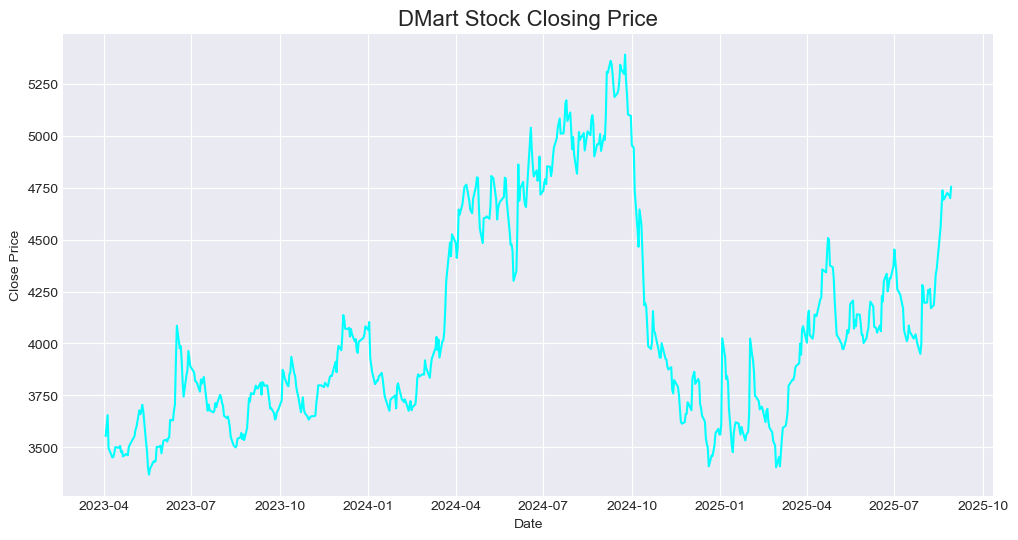

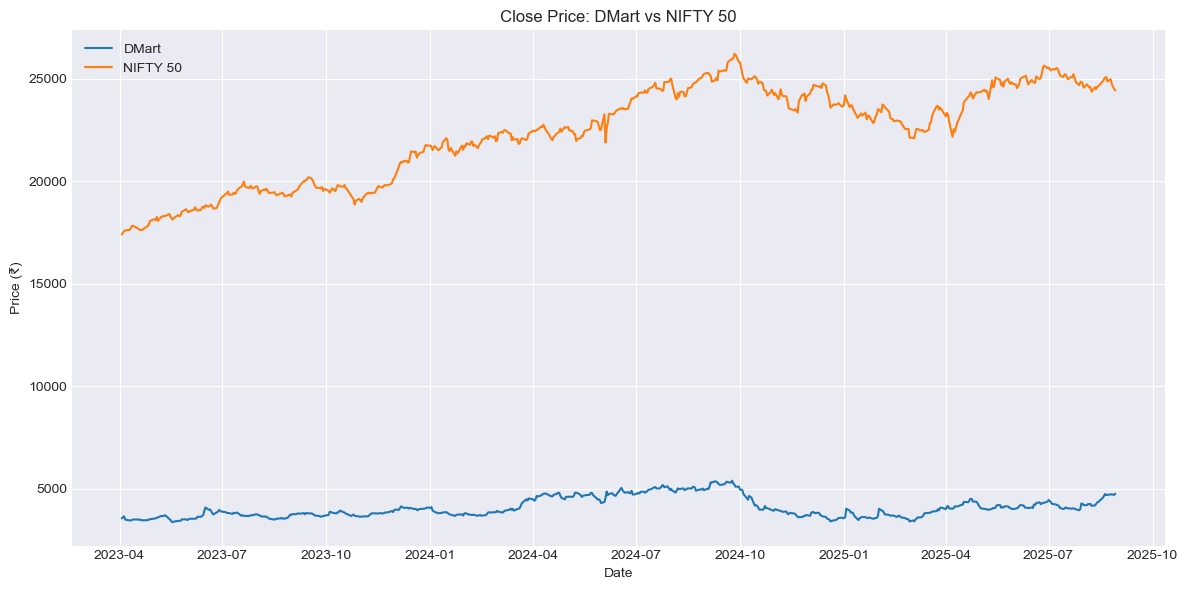

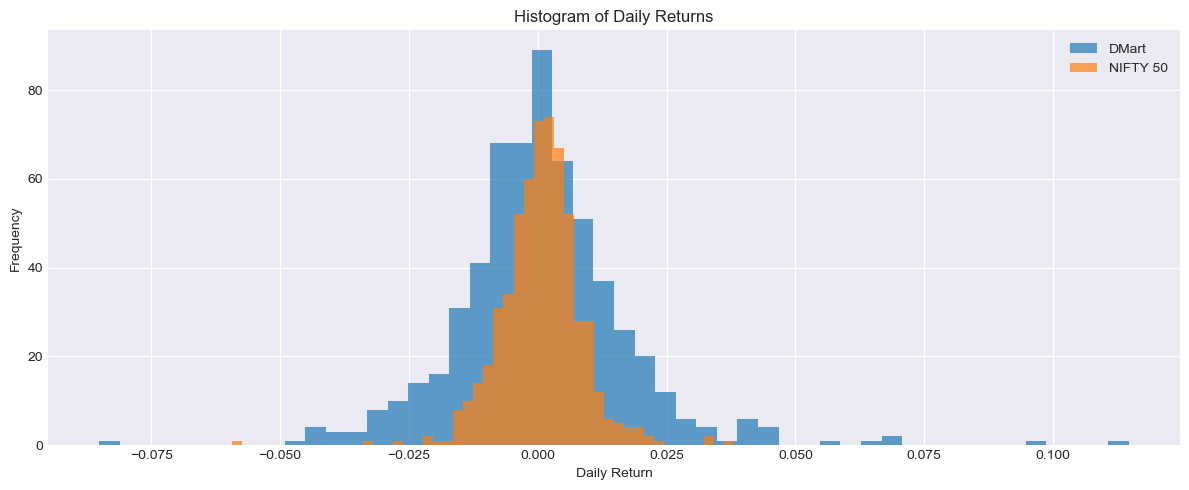

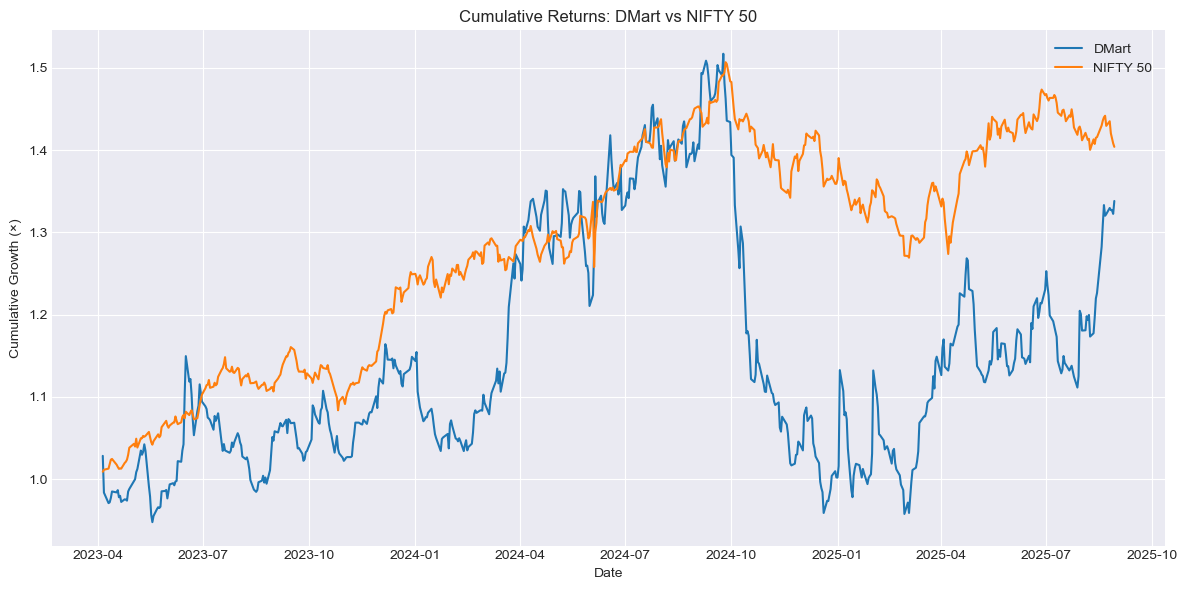

C:\Users\Maryam\AppData\Local\Temp\ipykernel_15536\2837715282.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dmart['Daily_Return'].dropna(), nifty['Daily_Return'].dropna()],


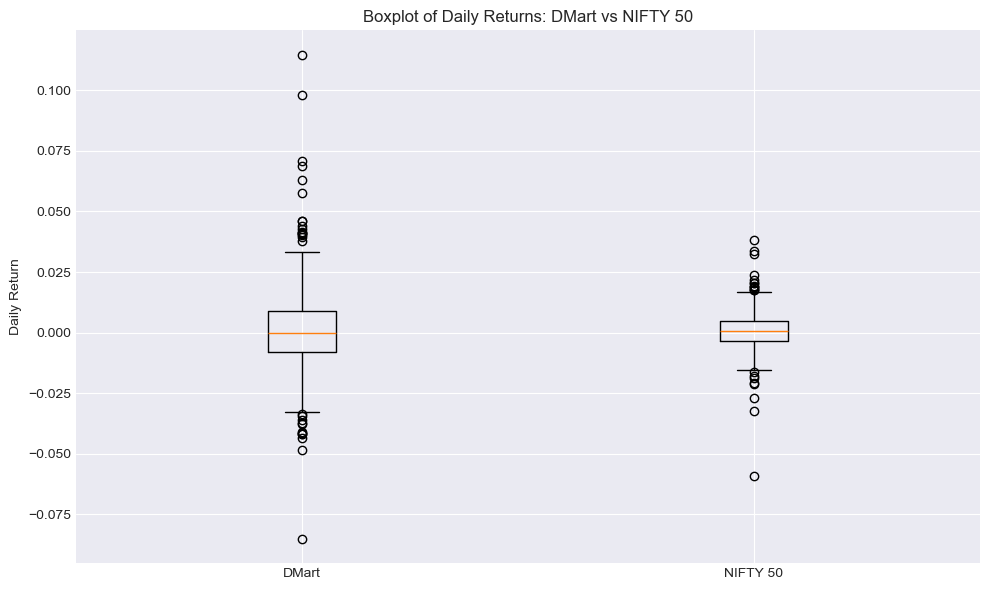

In [21]:
# =====================================
# STEP 2: EXPLORATORY DATA ANALYSIS
# =====================================

# Summary statistics
print("DMart Summary Stats:\n", dmart['Daily_Return'].describe())
print("\nNIFTY 50 Summary Stats:\n", nifty['Daily_Return'].describe())

# Volatility (annualized)
dmart_vol = dmart['Daily_Return'].std() * (252**0.5)
nifty_vol = nifty['Daily_Return'].std() * (252**0.5)
print(f"\nDMart Annualized Volatility: {dmart_vol:.2%}")
print(f"NIFTY 50 Annualized Volatility: {nifty_vol:.2%}")

# Correlation
corr = dmart['Daily_Return'].corr(nifty['Daily_Return'])
print(f"\nCorrelation between DMart and NIFTY 50 daily returns: {corr:.2f}")

# Dmart stock Closing price
plt.figure(figsize=(12,6))
plt.plot(dmart['Close'], color='cyan')
plt.title("DMart Stock Closing Price", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

# Plot Close Prices Dmart Vs Nifty50
plt.figure(figsize=(12,6))
plt.plot(dmart.index, dmart['Close'], label="DMart")
plt.plot(nifty.index, nifty['Close'], label="NIFTY 50")
plt.title("Close Price: DMart vs NIFTY 50")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Daily Returns Histogram
plt.figure(figsize=(12,5))
plt.hist(dmart['Daily_Return'].dropna(), bins=50, alpha=0.7, label="DMart")
plt.hist(nifty['Daily_Return'].dropna(), bins=50, alpha=0.7, label="NIFTY 50")
plt.title("Histogram of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Cumulative Returns
dmart['Cumulative'] = (1 + dmart['Daily_Return']).cumprod()
nifty['Cumulative'] = (1 + nifty['Daily_Return']).cumprod()

plt.figure(figsize=(12,6))
plt.plot(dmart.index, dmart['Cumulative'], label="DMart")
plt.plot(nifty.index, nifty['Cumulative'], label="NIFTY 50")
plt.title("Cumulative Returns: DMart vs NIFTY 50")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth (×)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Boxplot of Daily Returns
plt.figure(figsize=(10,6))
plt.boxplot([dmart['Daily_Return'].dropna(), nifty['Daily_Return'].dropna()],
            labels=['DMart', 'NIFTY 50'])
plt.title("Boxplot of Daily Returns: DMart vs NIFTY 50")
plt.ylabel("Daily Return")
plt.grid(True)
plt.tight_layout()
plt.show()


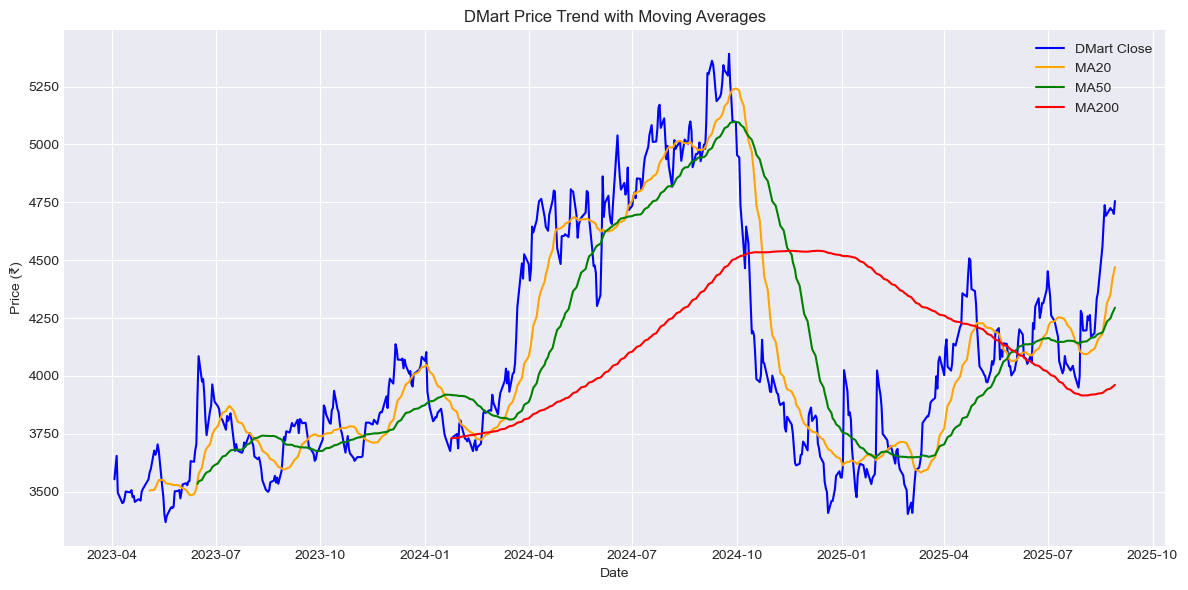

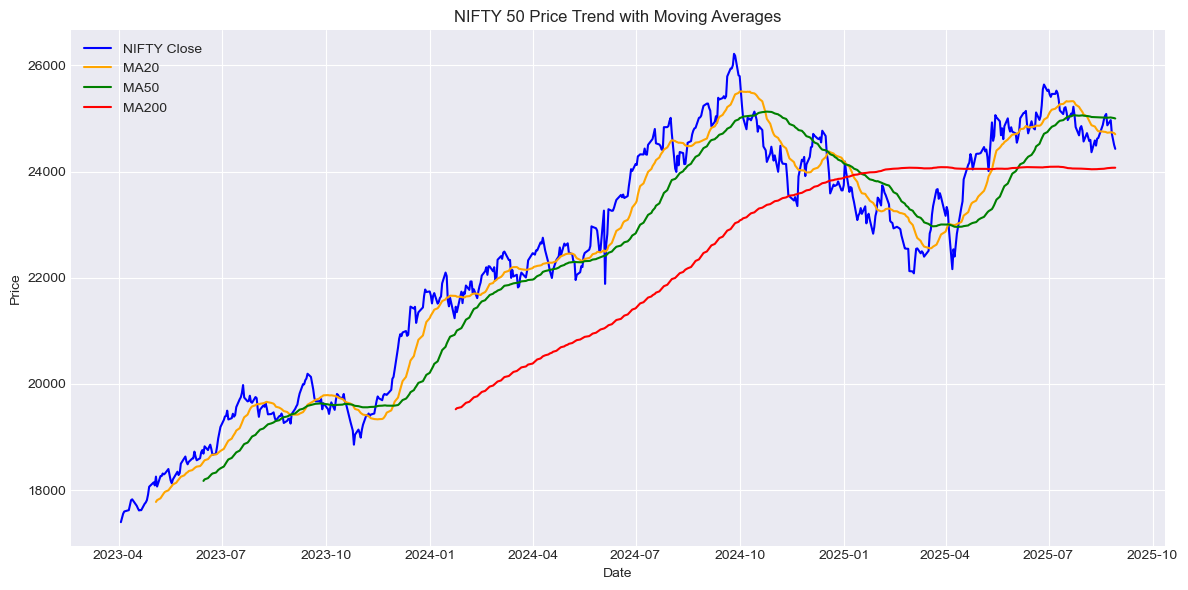

In [23]:
# Calculate moving averages
dmart['MA20'] = dmart['Close'].rolling(window=20).mean()
dmart['MA50'] = dmart['Close'].rolling(window=50).mean()
dmart['MA200'] = dmart['Close'].rolling(window=200).mean()

nifty['MA20'] = nifty['Close'].rolling(window=20).mean()
nifty['MA50'] = nifty['Close'].rolling(window=50).mean()
nifty['MA200'] = nifty['Close'].rolling(window=200).mean()

# Plot DMart trend with MAs
plt.figure(figsize=(12,6))
plt.plot(dmart.index, dmart['Close'], label='DMart Close', color='blue')
plt.plot(dmart.index, dmart['MA20'], label='MA20', color='orange')
plt.plot(dmart.index, dmart['MA50'], label='MA50', color='green')
plt.plot(dmart.index, dmart['MA200'], label='MA200', color='red')
plt.title('DMart Price Trend with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot NIFTY trend with MAs
plt.figure(figsize=(12,6))
plt.plot(nifty.index, nifty['Close'], label='NIFTY Close', color='blue')
plt.plot(nifty.index, nifty['MA20'], label='MA20', color='orange')
plt.plot(nifty.index, nifty['MA50'], label='MA50', color='green')
plt.plot(nifty.index, nifty['MA200'], label='MA200', color='red')
plt.title('NIFTY 50 Price Trend with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#### ✅ Key Conclusions from Step 2

##### Risk: DMart = high risk (volatility 27%) vs NIFTY = safer (volatility 12.5%).
##### Reward potential: DMart has higher daily return peaks → higher upside.
##### Market behavior: DMart barely follows NIFTY (corr 0.21) → it’s somewhat independent.
##### Investment vibe: DMart = aggressive play; NIFTY = steady, long-term growth.

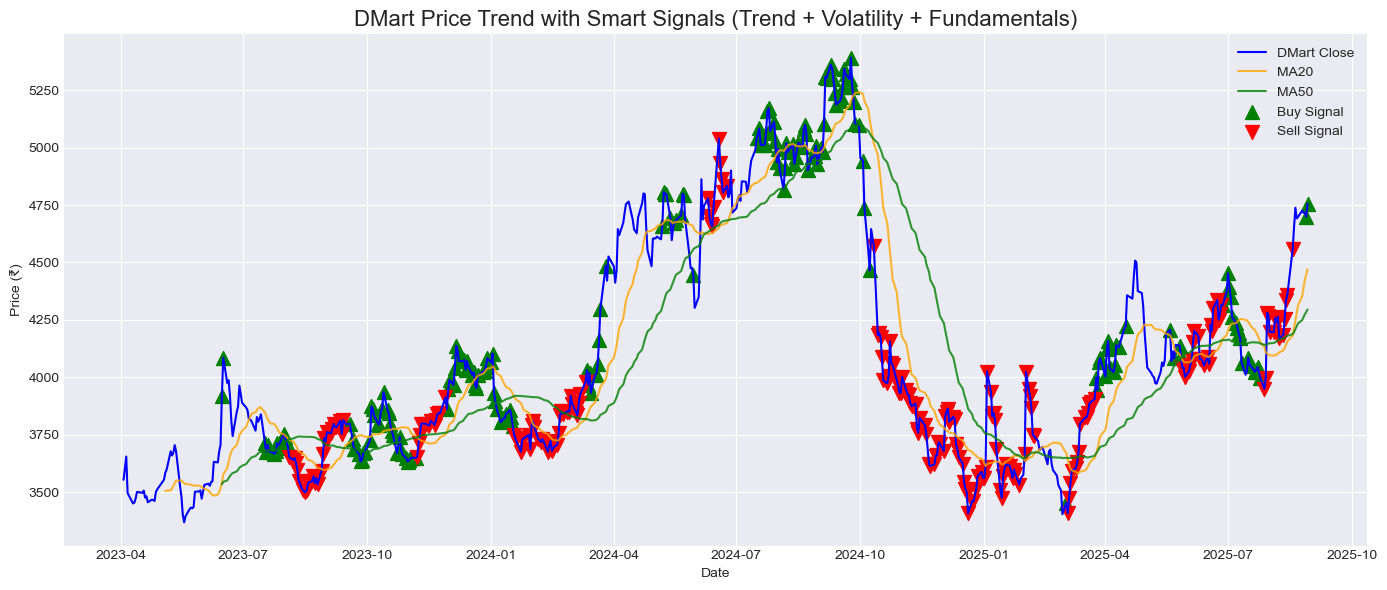

In [25]:
# --- Trend: Moving Averages ---
dmart['MA20'] = dmart['Close'].rolling(window=20).mean()
dmart['MA50'] = dmart['Close'].rolling(window=50).mean()

# Generate basic trend signals: 1=Buy, -1=Sell
dmart['Signal'] = 0
dmart.iloc[49:, dmart.columns.get_loc('Signal')] = np.where(
    dmart['MA20'].iloc[49:] > dmart['MA50'].iloc[49:], 1, -1
)

# --- Volatility: 20-day rolling annualized ---
dmart['Volatility'] = dmart['Close'].pct_change().rolling(20).std() * np.sqrt(252)

# Define volatility thresholds
low_vol = dmart['Volatility'].quantile(0.33)
high_vol = dmart['Volatility'].quantile(0.66)

# Adjust trend signal based on volatility
dmart['Combined_Signal'] = dmart['Signal']  # start with trend signal
dmart.loc[(dmart['Signal'] == 1) & (dmart['Volatility'] > high_vol), 'Combined_Signal'] = 0  # Cautious buy
dmart.loc[(dmart['Signal'] == -1) & (dmart['Volatility'] < low_vol), 'Combined_Signal'] = -2  # Strong sell

# --- Fundamentals: hypothetical factor based on PAT growth / ROE ---
fundamental_strength = 0.85  # 0-1 scale (1=very strong, 0=weak)
dmart['Combined_Signal'] = dmart['Combined_Signal'] * fundamental_strength

# --- Plot Trend + Signals ---
plt.figure(figsize=(14,6))
plt.plot(dmart.index, dmart['Close'], label='DMart Close', color='blue')
plt.plot(dmart.index, dmart['MA20'], label='MA20', color='orange', alpha=0.8)
plt.plot(dmart.index, dmart['MA50'], label='MA50', color='green', alpha=0.8)

# Plot buy/sell markers
plt.scatter(dmart.index[dmart['Combined_Signal']>0], dmart['Close'][dmart['Combined_Signal']>0],
            marker='^', color='green', label='Buy Signal', s=100)
plt.scatter(dmart.index[dmart['Combined_Signal']<0], dmart['Close'][dmart['Combined_Signal']<0],
            marker='v', color='red', label='Sell Signal', s=100)

plt.title('DMart Price Trend with Smart Signals (Trend + Volatility + Fundamentals)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:
# Risk based on volatility
vol = dmart['Daily_Return'].std() * (252**0.5)  # annualized

if vol > 0.2:
    vol_risk = 'Risky'
elif vol > 0.1:
    vol_risk = 'Moderate'
else:
    vol_risk = 'Beneficial'

# Risk based on Q1 / Min
q1 = dmart['Daily_Return'].quantile(0.25)
min_ret = dmart['Daily_Return'].min()

if q1 < -0.05 or min_ret < -0.1:
    quartile_risk = 'Risky'
elif q1 < -0.02:
    quartile_risk = 'Moderate'
else:
    quartile_risk = 'Beneficial'

# Risk based on trend (price vs MA200)
if dmart['Close'].iloc[-1] > dmart['MA200'].iloc[-1]:
    trend_risk = 'Beneficial'
elif dmart['Close'].iloc[-1] < dmart['MA200'].iloc[-1]:
    trend_risk = 'Risky'
else:
    trend_risk = 'Moderate'

# Combine all metrics
metrics = [vol_risk, quartile_risk, trend_risk]
if metrics.count('Risky') >= 2:
    overall_class = 'Risky'
elif metrics.count('Beneficial') >= 2:
    overall_class = 'Beneficial'
else:
    overall_class = 'Moderate'

print(f"DMart Classification based on 2-year data: {overall_class}")

DMart Classification based on 2-year data: Beneficial


##### “DMart shows manageable volatility, strong upward trends, and solid fundamentals, making it a beneficial choice for medium-to-long-term investment.”

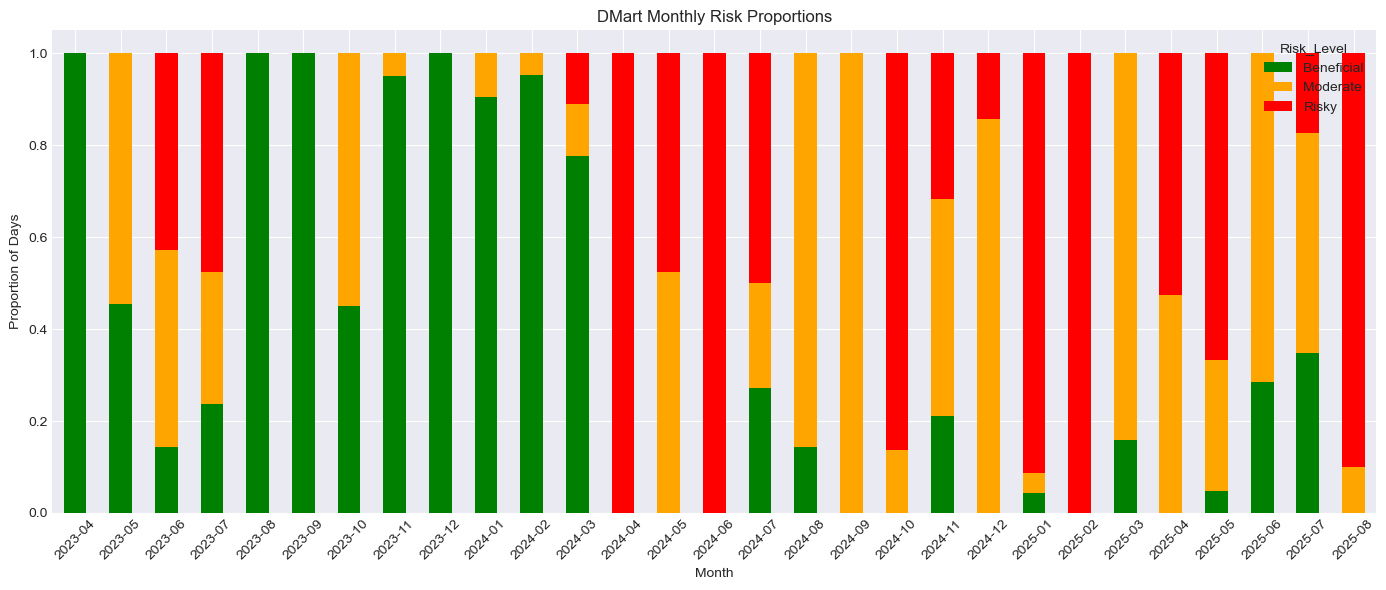

In [29]:
# Step 1: Recalculate Risk_Level using quantiles for better differentiation

vol = dmart['Close'].pct_change().rolling(window=20).std()
quantiles = vol.quantile([0.33, 0.66])
def risk_label_q(v):
    if v > quantiles[0.66]:
        return 'Risky'
    elif v > quantiles[0.33]:
        return 'Moderate'
    else:
        return 'Beneficial'
dmart['Risk_Level'] = vol.apply(risk_label_q)

# Step 2: Aggregate by month
monthly_risk_counts = dmart.groupby([dmart.index.to_period('M'), 'Risk_Level']).size().unstack(fill_value=0)

# Step 3: Normalize to proportion
monthly_risk_prop = monthly_risk_counts.div(monthly_risk_counts.sum(axis=1), axis=0)

# Step 4: Plot stacked bar chart
monthly_risk_prop.plot(kind='bar', stacked=True, figsize=(14,6),
                       color={'Risky':'red','Moderate':'orange','Beneficial':'green'})
plt.title("DMart Monthly Risk Proportions")
plt.ylabel("Proportion of Days")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\Maryam\AppData\Local\Temp\ipykernel_15536\4244635619.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


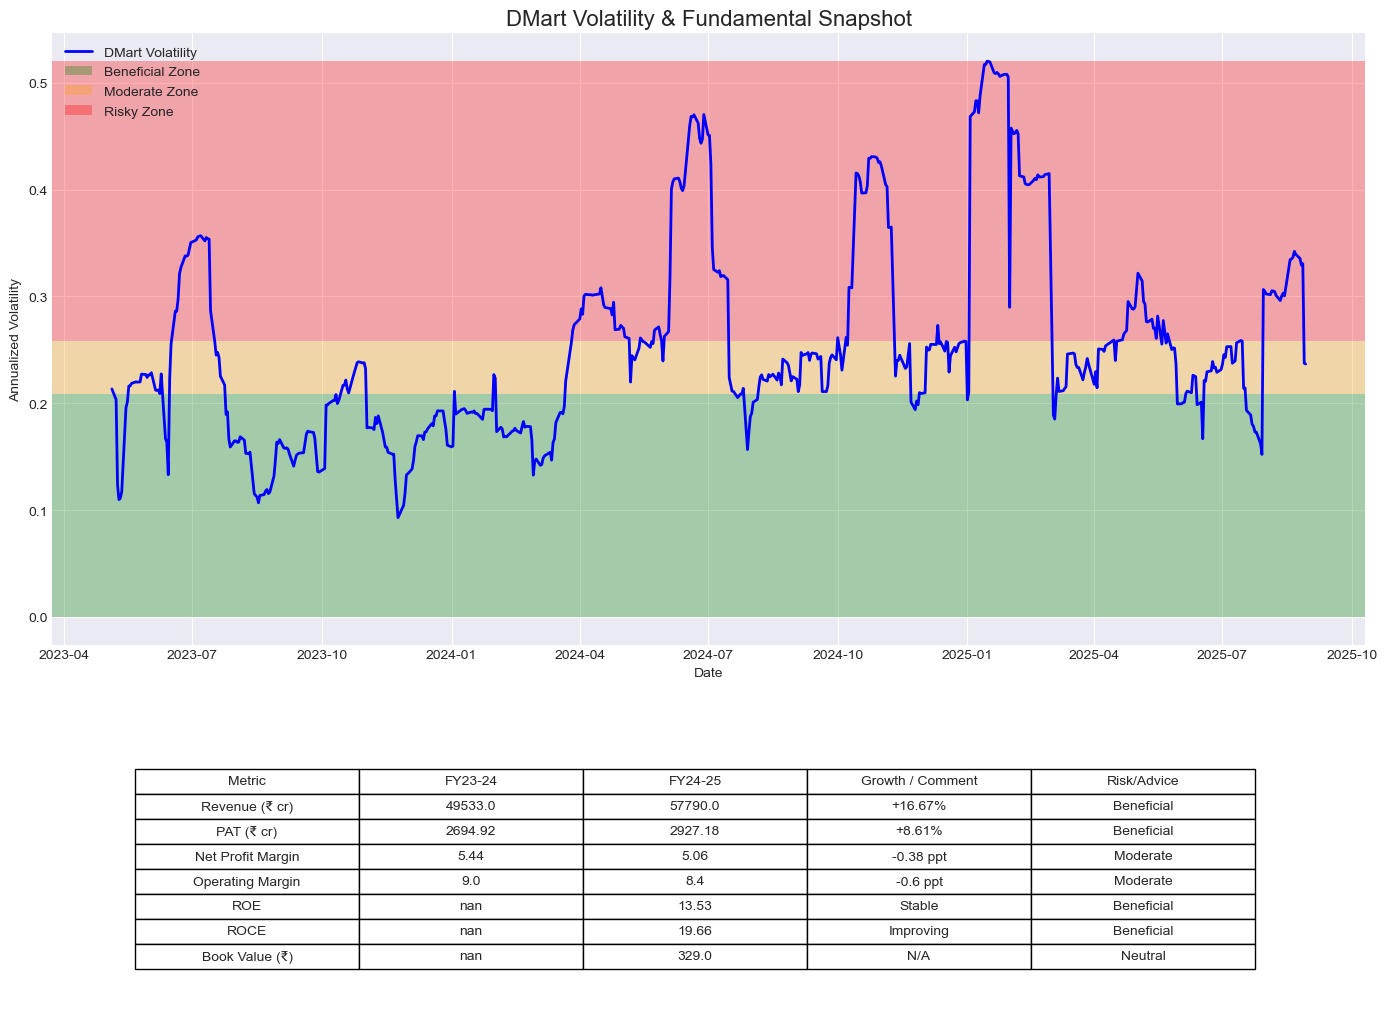

In [30]:
# --- Fundamental data (FY23-24 → FY24-25) ---
fundamentals = {
    'Metric': ['Revenue (₹ cr)', 'PAT (₹ cr)', 'Net Profit Margin', 'Operating Margin', 'ROE', 'ROCE', 'Book Value (₹)'],
    'FY23-24': [49533, 2694.92, 5.44, 9.0, None, None, None],
    'FY24-25': [57790, 2927.18, 5.06, 8.4, 13.53, 19.66, 329],
    'Growth / Comment': ['+16.67%', '+8.61%', '-0.38 ppt', '-0.6 ppt', 'Stable', 'Improving', 'N/A'],
    'Risk/Advice': ['Beneficial', 'Beneficial', 'Moderate', 'Moderate', 'Beneficial', 'Beneficial', 'Neutral']
}

fund_df = pd.DataFrame(fundamentals)

# --- Stock volatility data (example: DMart 20-day rolling) ---
# Assuming dmart['Close'] exists
dmart['Volatility'] = dmart['Close'].pct_change().rolling(20).std() * (252**0.5)

# Risk thresholds
low = dmart['Volatility'].quantile(0.33)
med = dmart['Volatility'].quantile(0.66)
high = dmart['Volatility'].max()

# --- Plot ---
fig, ax = plt.subplots(figsize=(14,7))

# Volatility line
ax.plot(dmart.index, dmart['Volatility'], color='blue', label='DMart Volatility', linewidth=2)

# Risk zones
ax.axhspan(0, low, facecolor='green', alpha=0.3, label='Beneficial Zone')
ax.axhspan(low, med, facecolor='orange', alpha=0.3, label='Moderate Zone')
ax.axhspan(med, high, facecolor='red', alpha=0.3, label='Risky Zone')

# Titles & labels
ax.set_title('DMart Volatility & Fundamental Snapshot', fontsize=16)
ax.set_ylabel('Annualized Volatility')
ax.set_xlabel('Date')
ax.legend(loc='upper left')

# Add fundamentals table below graph
from matplotlib.table import Table
table_ax = plt.gcf().add_axes([0.1, -0.45, 0.8, 0.4])  # Adjust position
table_ax.axis('off')
table = table_ax.table(cellText=fund_df.values,
                       colLabels=fund_df.columns,
                       cellLoc='center',
                       loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.tight_layout()
plt.show()


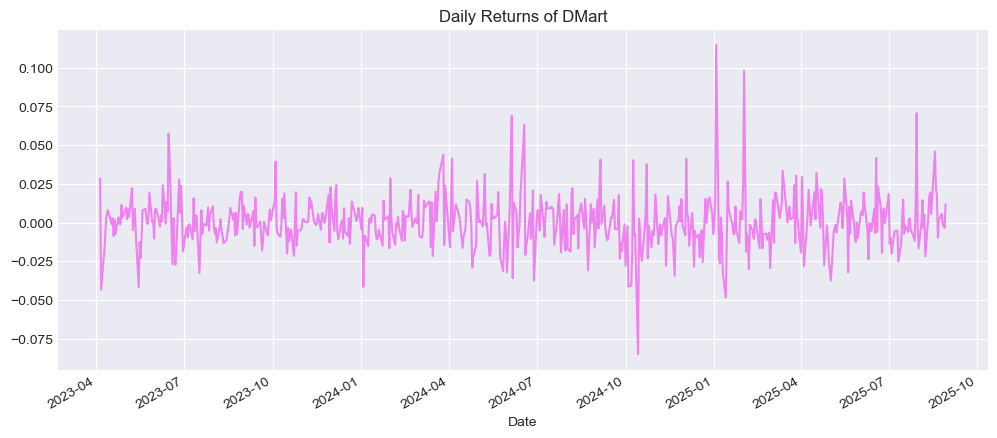

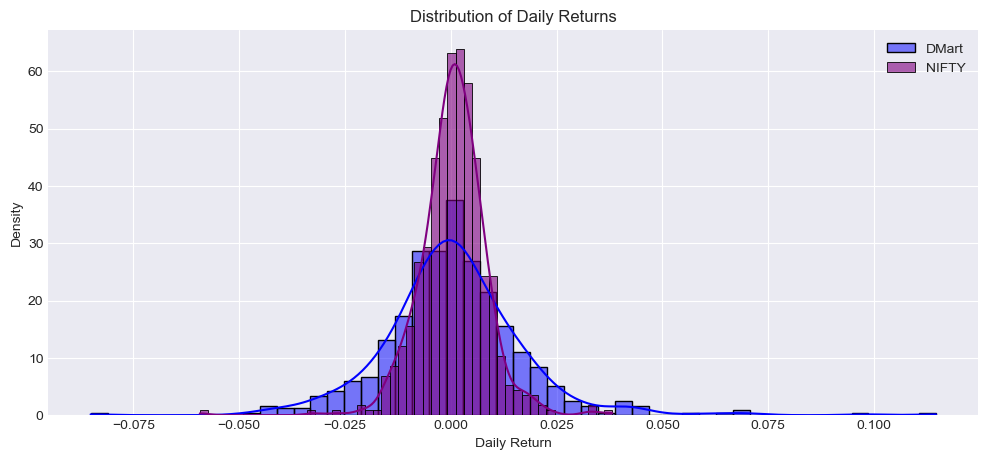

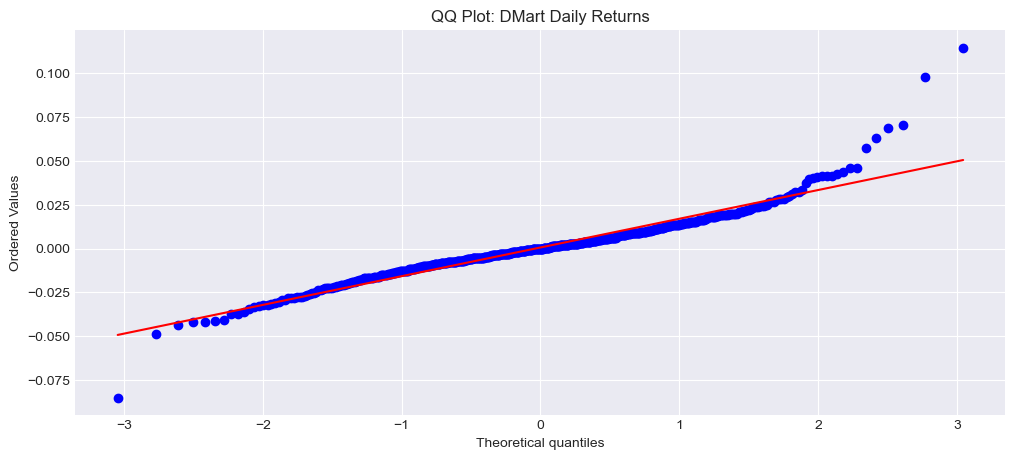

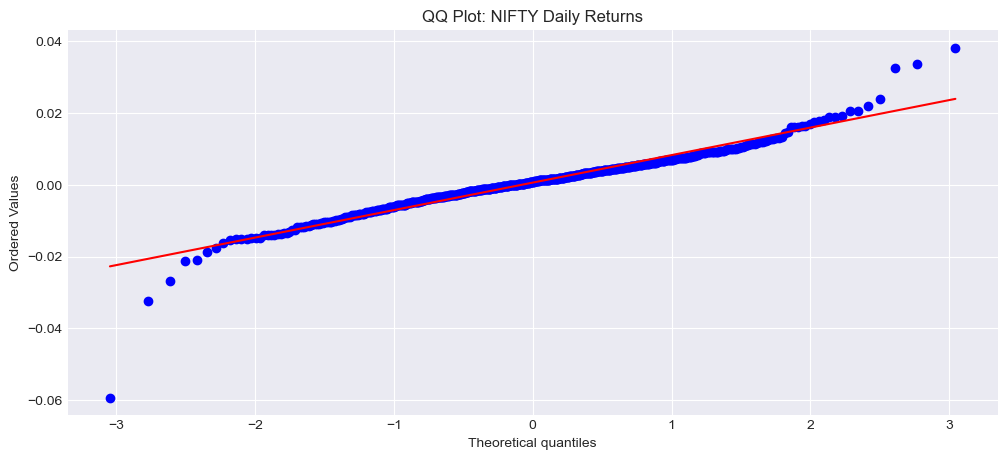

DMart Shapiro-Wilk test: ShapiroResult(statistic=0.923823708519189, pvalue=9.073958041644624e-17)
NIFTY Shapiro-Wilk test: ShapiroResult(statistic=0.9380299904232238, pvalue=5.398837713607557e-15)


In [31]:
# =====================================
# STEP 3: RETURNS & NORMALITY CHECK AND SOME TESTS
# =====================================

# DMart returns
dmart['Daily_Return'] = dmart['Close'].pct_change()
dmart['Daily_Return'].dropna().plot(figsize=(12,5), color='violet')
plt.title("Daily Returns of DMart")
plt.show()

# Extract clean return series
dmart_returns = dmart['Daily_Return'].dropna()
nifty_returns = nifty['Daily_Return'].dropna()

# Histogram + KDE
plt.figure(figsize=(12,5))
sns.histplot(dmart_returns, kde=True, color='blue', label='DMart', bins=50, stat="density")
sns.histplot(nifty_returns, kde=True, color='purple', label='NIFTY', bins=50, stat="density", alpha=0.6)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Density')
plt.legend()
plt.show()

# QQ-Plot
plt.figure(figsize=(12,5))
stats.probplot(dmart_returns, dist="norm", plot=plt)
plt.title("QQ Plot: DMart Daily Returns")
plt.show()

plt.figure(figsize=(12,5))
stats.probplot(nifty_returns, dist="norm", plot=plt)
plt.title("QQ Plot: NIFTY Daily Returns")
plt.show()

# Shapiro-Wilk test for normality
shapiro_dmart = stats.shapiro(dmart_returns)
shapiro_nifty = stats.shapiro(nifty_returns)

print("DMart Shapiro-Wilk test:", shapiro_dmart)
print("NIFTY Shapiro-Wilk test:", shapiro_nifty)


### Normality Check Results

##### Shapiro-Wilk Test: Both DMart & NIFTY returns gave p-values < 0.05, technically rejecting perfect normality.

##### Q-Q Plot & Histogram: Both datasets are bell-shaped and points lie close to the diagonal, suggesting approximate normality.

#### Interpretation:

##### Statistical tests are highly sensitive with large samples, flagging even minor deviations.

##### Visual inspection confirms the returns are approximately normal, which is sufficient for further statistical analysis.

#### 🚀 Why we did both?

##### Levene → check the risk profile (spread of returns).
##### T-test → check the reward profile (average return).

In [36]:
# Levene’s test (check variance equality)
levene_test = stats.levene(dmart_returns, nifty_returns)
print("Levene’s Test for Equal Variance:", levene_test)

# Two-sample t-test (Welch’s by default, robust if variances not equal)
ttest = stats.ttest_ind(dmart_returns, nifty_returns, equal_var=False)
print("T-test Result:", ttest)


Levene’s Test for Equal Variance: LeveneResult(statistic=121.97237115202368, pvalue=4.6428373301471715e-27)
T-test Result: TtestResult(statistic=0.03958028351272888, pvalue=0.9684371823596601, df=837.252828140166)


### 📊 Levene’s Test

###### Statistic = 121.97, p-value ≈ 4.6e-27 (basically 0)
###### 👉 That means variances are NOT equal.
###### DMart and NIFTY returns have different volatility/risk profiles.
###### So one is much more "jumpy" than the other.

### 📊 T-Test (Welch’s)

###### Statistic = 0.0395, p-value ≈ 0.968
###### 👉 p-value > 0.05 → no significant difference in mean daily returns.
###### So, on average, DMart and NIFTY earn almost the same per day.

In [38]:
# ===================================
# Difference of means (DMART-NIFTY50)
# ===================================
mean_diff = dmart_returns.mean() - nifty_returns.mean()

# Welch-Satterthwaite Standard Error
n1, n2 = len(dmart_returns), len(nifty_returns)
s1, s2 = dmart_returns.var(ddof=1), nifty_returns.var(ddof=1)
se_diff = np.sqrt(s1/n1 + s2/n2)

# Welch-Satterthwaite degrees of freedom
df = (s1/n1 + s2/n2)**2 / (((s1/n1)**2)/(n1-1) + ((s2/n2)**2)/(n2-1))

# Confidence Interval
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df)
ci_low = mean_diff - t_crit * se_diff
ci_high = mean_diff + t_crit * se_diff

print(f"95% Confidence Interval for Mean Difference (DMart - NIFTY): ({ci_low}, {ci_high})")

# ==============
# DMart returns
# ==============

returns = dmart['Daily_Return'].dropna()
mean = returns.mean()
sem = stats.sem(returns)  # standard error
ci = stats.t.interval(0.95, len(returns)-1, loc=mean, scale=sem)

print("95% Confidence Interval for Mean Return:", ci)

# ==================================================================
# One-sample t-test: is DMart's mean daily return different from 0?
# ==================================================================

dmart_returns = dmart['Daily_Return'].dropna()
t_stat, p_value = stats.ttest_1samp(dmart_returns, 0)

print("DMart One-Sample t-test:")
print(f"T-statistic = {t_stat}")
print(f"P-value = {p_value}")
print(f"Mean Return = {dmart_returns.mean()}")

95% Confidence Interval for Mean Difference (DMart - NIFTY): (-0.0014830206124397277, 0.001544062346391656)
95% Confidence Interval for Mean Return: (-0.0007394186124931215, 0.002007797758757834)
DMart One-Sample t-test:
T-statistic = 0.9067584790108696
P-value = 0.3649028334300285
Mean Return = 0.0006341895731323563


###### DMart ≈ NIFTY in average returns (no clear winner).
###### DMart’s mean daily return is slightly positive, but not statistically significant.
###### Long-term, that small positive can still snowball into big annual gains → but it’s moderate risk, moderate reward

In [41]:
# ================================
# DMART Annualized Return & Volatility
# ================================

# Mean & Std (daily)
mean_daily = dmart_returns.mean()
vol_daily = dmart_returns.std()

# Annualize
trading_days = 252
annual_return = (1 + mean_daily) ** trading_days - 1
annual_volatility = vol_daily * np.sqrt(trading_days)

print("DMart Annualized Return: {:.2f}%".format(annual_return * 100))
print("DMart Annualized Volatility: {:.2f}%".format(annual_volatility * 100))

# if the stock is risky, but does the return justify the rollercoaster?

# Assume risk-free rate (e.g. 6% annual ~ India 10Y govt bond)
risk_free_rate = 0.06  

sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility
print("Sharpe Ratio for DMart:", sharpe_ratio)


# ===========================
# NIFTY50 Annual Return, Volatility, Sharpe
# ===========================

# Mean & Std (daily)
mean_daily_nifty = nifty_returns.mean()
vol_daily_nifty = nifty_returns.std()

# Annualize
annual_return_nifty = (1 + mean_daily_nifty) ** trading_days - 1
annual_volatility_nifty = vol_daily_nifty * np.sqrt(trading_days)

print("NIFTY50 Annualized Return: {:.2f}%".format(annual_return_nifty * 100))
print("NIFTY50 Annualized Volatility: {:.2f}%".format(annual_volatility_nifty * 100))

# Sharpe Ratio for NIFTY
sharpe_ratio_nifty = (annual_return_nifty - risk_free_rate) / annual_volatility_nifty
print("Sharpe Ratio for NIFTY50:", sharpe_ratio_nifty)

DMart Annualized Return: 17.32%
DMart Annualized Volatility: 27.06%
Sharpe Ratio for DMart: 0.4184665404278555
NIFTY50 Annualized Return: 16.43%
NIFTY50 Annualized Volatility: 12.55%
Sharpe Ratio for NIFTY50: 0.8304840499054895


#### Interpretation:

###### DMart: higher return (17.3%) but way riskier (27.1% volatility).
###### NIFTY50: slightly lower return (16.4%) but safer, better risk-adjusted (Sharpe 0.83 vs 0.42).
###### Takeaway: DMart = thrill, NIFTY50 = smart steady.


In [43]:
# =====================================
# STEP 4: RISK ANALYSIS (VOLATILITY & BETA)
# =====================================

# Volatility
volatility = dmart['Daily_Return'].std() * np.sqrt(252)  # annualized
print(f"Annualized Volatility: {volatility:.2%}")

# Beta vs NIFTY
nifty = pd.read_csv(r"C:\Users\Maryam\MSc\Field Project\NIFTY50_data.csv")
nifty['Date'] = pd.to_datetime(nifty['Date'], dayfirst=True)
nifty.set_index('Date', inplace=True)
nifty['Return'] = nifty['Close'].pct_change()

combined = pd.concat([dmart['Daily_Return'], nifty['Return']], axis=1).dropna()
X = sm.add_constant(combined['Return'])
y = combined['Daily_Return']
model = sm.OLS(y, X).fit()
beta = model.params[1]
print(f"Beta vs NIFTY: {beta:.2f}")

Annualized Volatility: 27.06%
Beta vs NIFTY: 0.45


C:\Users\Maryam\AppData\Local\Temp\ipykernel_15536\155077158.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]


##### What is Beta?
##### -Beta is like the attitude meter of your stock compared to the market.

##### DMart vs NIFTY Risk Summary:

##### Volatility: 27.06% → fairly wiggly in price; expect swings.
##### Beta: 0.45 → moves less than half as much as NIFTY; calmer than the market.
##### Basically, DMart = “rebellious angel”: a bit wild on its own, chill compared to the crowd


📌 Transition Probability Matrix:
               Up      Down   Neutral
Up       0.525180  0.395683  0.079137
Down     0.390511  0.547445  0.062044
Neutral  0.619048  0.333333  0.047619


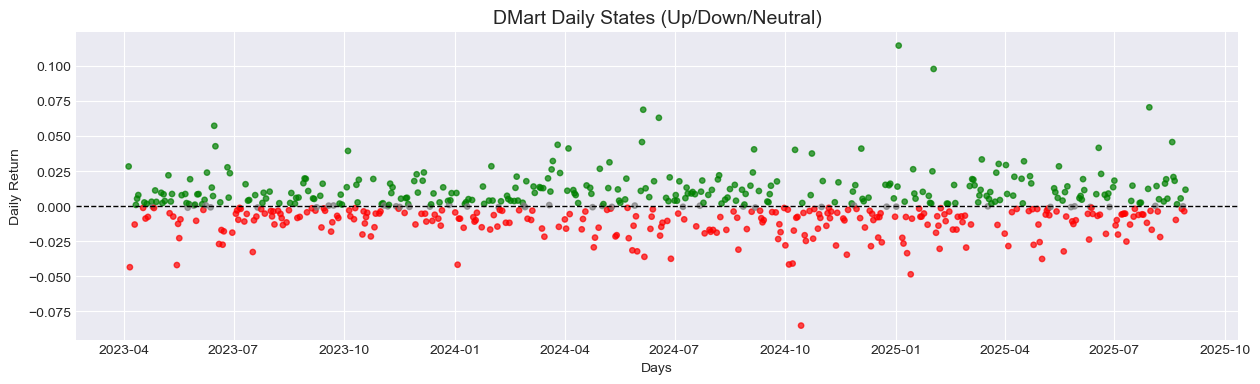

In [46]:
# =================================================================
# Step 5:📊 DMart Stock State Classification (3-state Markov Chain model)
# =================================================================

# Calculate daily returns
dmart['Daily_Return'] = dmart['Close'].pct_change()

# -----------------------------
# 1. Categorize returns into states
# -----------------------------
def categorize_return(x, threshold=0.001):  
    """
    Classify returns into three states:
    - Up: Return > +0.1%
    - Down: Return < -0.1%
    - Neutral: Between -0.1% and +0.1%
    """
    if x > threshold:
        return 'Up'
    elif x < -threshold:
        return 'Down'
    else:
        return 'Neutral'

dmart['State'] = dmart['Daily_Return'].apply(categorize_return)

# -----------------------------
# 2. Build Transition Matrix
# -----------------------------
states = ['Up', 'Down', 'Neutral']

# Initialize matrix
transition_matrix = pd.DataFrame(0, index=states, columns=states, dtype=float)

# Count transitions between states
for (prev, curr) in zip(dmart['State'][:-1], dmart['State'][1:]):
    transition_matrix.loc[prev, curr] += 1

# Convert counts → probabilities
transition_matrix = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)

print("\n📌 Transition Probability Matrix:")
print(transition_matrix)

# -----------------------------
# 3. Visualization
# -----------------------------
# Assign colors for states
state_colors = {
    'Up': 'green',
    'Down': 'red',
    'Neutral': 'gray'
}

# Map each day’s state → color
colors = dmart['State'].map(state_colors)

plt.figure(figsize=(15,4))
plt.scatter(dmart.index, dmart['Daily_Return'], c=colors, alpha=0.7, s=15)
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title("DMart Daily States (Up/Down/Neutral)", fontsize=14)
plt.xlabel("Days")
plt.ylabel("Daily Return")
plt.show()


##### “DMart daily returns show mild momentum: up-days often follow up-days, down-days slightly persist, and neutral days are likely to become up-days. Overall, the stock exhibits a moderately stable pattern suitable for trend-following strategies.”

In [49]:
!pip install hmmlearn

Bull state: 1, Bear state: 0


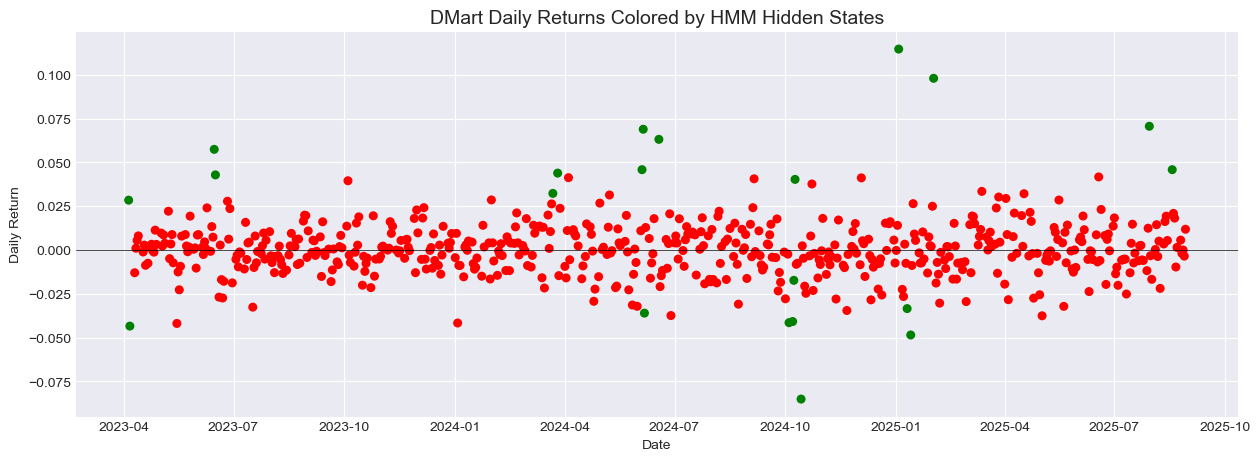

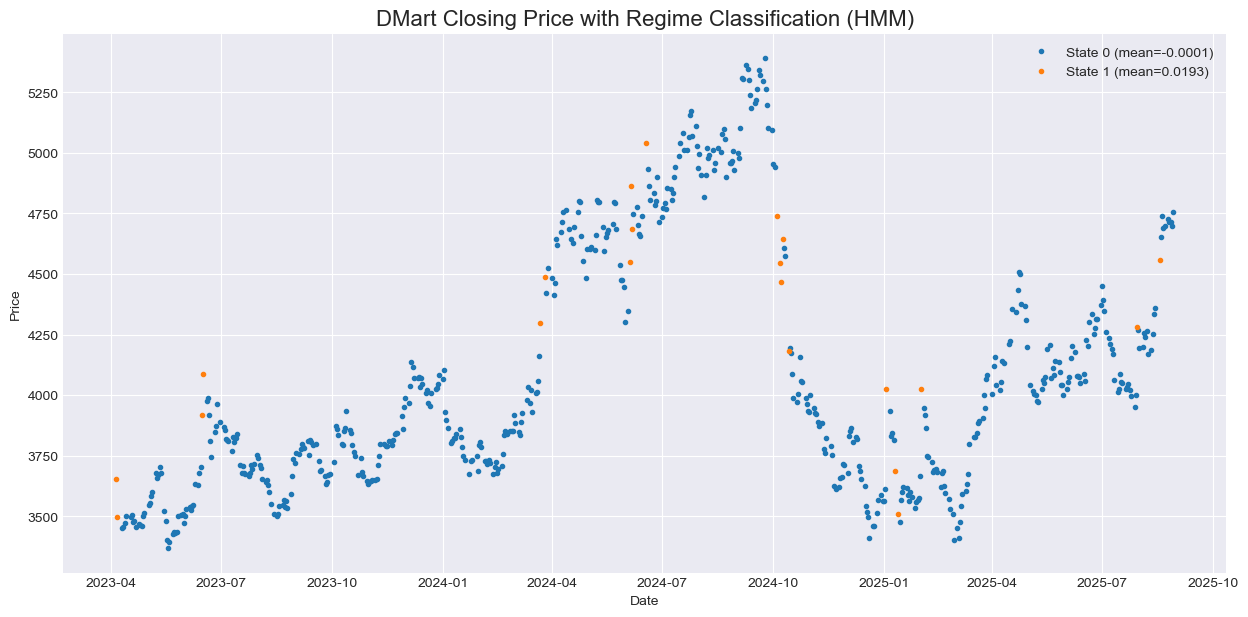

Transition Matrix:
            To 0      To 1
From 0  0.960979  0.039021
From 1  0.574082  0.425918

State 0:
  Mean return = -0.00005
  Volatility  = 0.01347

State 1:
  Mean return = 0.01934
  Volatility  = 0.05520


In [50]:
# ==========================================
# Step 6: DMart Stock HMM Analysis (2-state: Bull/Bear)
# ==========================================

from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make sure 'returns' is a pandas Series of daily returns
# returns = dmart_clean['Daily_Return']

# -----------------------------
# 1. Fit a 2-state Gaussian HMM
# -----------------------------
model = GaussianHMM(
    n_components=2,          # Two hidden states: Bull & Bear
    covariance_type="full",  # Allows correlation structure
    n_iter=1000,             # Max iterations
    random_state=42
)

# Fit expects 2D array, reshape your 1D returns
model.fit(returns.values.reshape(-1, 1))

# -----------------------------
# 2. Predict hidden states
# -----------------------------
hidden_states = model.predict(returns.values.reshape(-1, 1))
dmart_clean['Regime'] = hidden_states

# Identify Bull and Bear states
state_means = [returns[hidden_states == i].mean() for i in range(model.n_components)]
bear_state = np.argmin(state_means)
bull_state = np.argmax(state_means)
print(f"Bull state: {bull_state}, Bear state: {bear_state}")

# -----------------------------
# 3. Visualize returns colored by regimes
# -----------------------------
plt.figure(figsize=(15, 5))
colors = np.array(['red', 'green'])  # Red = Bear, Green = Bull
plt.scatter(dmart_clean.index, dmart_clean['Daily_Return'],
            c=colors[dmart_clean['Regime'].astype(int)], s=30)
plt.axhline(0, color='black', linewidth=0.5)
plt.title('DMart Daily Returns Colored by HMM Hidden States', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.show()

# -----------------------------
# 4. Visualize closing price with regimes
# -----------------------------
plt.figure(figsize=(15, 7))
for i in range(model.n_components):
    mask = (hidden_states == i)
    plt.plot(
        dmart_clean.index[mask],
        dmart_clean['Close'][mask],
        '.',
        label=f"State {i} (mean={returns[hidden_states == i].mean():.4f})"
    )
plt.title("DMart Closing Price with Regime Classification (HMM)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# -----------------------------
# 5. Transition matrix
# -----------------------------
trans_df = pd.DataFrame(
    model.transmat_,
    columns=[f"To {i}" for i in range(model.n_components)],
    index=[f"From {i}" for i in range(model.n_components)]
)
print("Transition Matrix:")
print(trans_df)

# -----------------------------
# 6. Regime statistics
# -----------------------------
for i in range(model.n_components):
    mean_return = returns[hidden_states == i].mean()
    volatility = returns[hidden_states == i].std()
    print(f"\nState {i}:")
    print(f"  Mean return = {mean_return:.5f}")
    print(f"  Volatility  = {volatility:.5f}")


##### "HMM analysis identifies two hidden regimes in DMart: Bear days with slight negative returns and low volatility, and Bull days with strong positive returns but higher volatility. Bear states tend to persist longer, while Bull states are less stable, indicating moderate trend stability and occasional high-return opportunities.”

Expected Price (mean): 4851.64
Median Price: 4838.68
5% - 95% Confidence Interval: 4177.46 - 5590.37


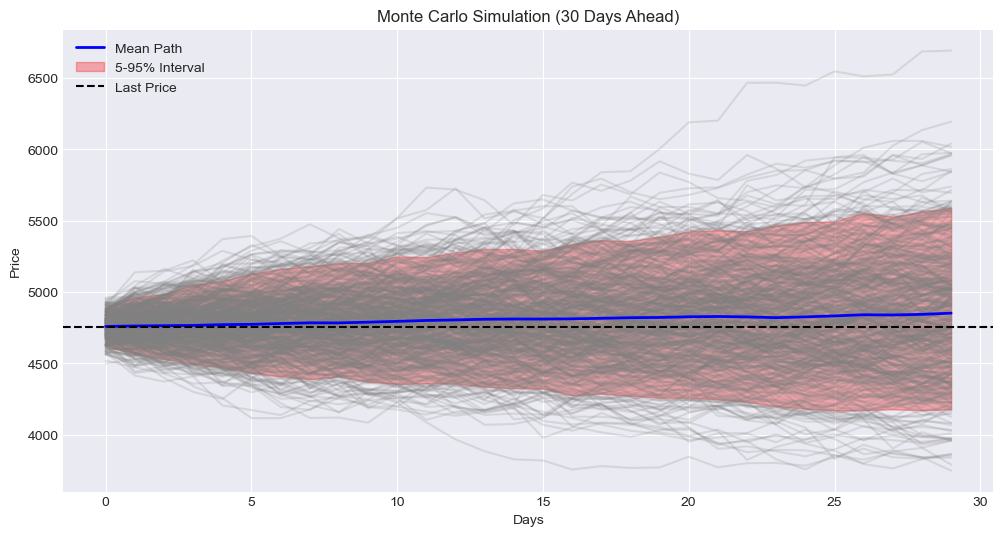

In [52]:
# =====================================
# STEP 7: FUTURE PRICE PREDICTION (MONTE CARLO)
# =====================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Monte Carlo Parameters
# -----------------------------
S0 = float(dmart_clean['Close'].iloc[-1])  # Last observed price from Step 6
mu = returns.mean()                        # Mean daily return
sigma = returns.std()                      # Std dev of daily returns
T = 30                                     # Days to simulate
simulations = 500                          # Number of simulation paths

# -----------------------------
# Run Monte Carlo Simulation
# -----------------------------
np.random.seed(42)
simulated_paths = np.zeros((T, simulations))

for i in range(simulations):
    daily_returns = np.random.normal(mu, sigma, T)
    simulated_paths[:, i] = S0 * np.cumprod(1 + daily_returns)

# -----------------------------
# Calculate Final Day Stats
# -----------------------------
final_prices = simulated_paths[-1]  # Prices at day T
expected_price = final_prices.mean()
median_price = np.median(final_prices)
lower_bound = np.percentile(final_prices, 5)
upper_bound = np.percentile(final_prices, 95)

print(f"Expected Price (mean): {expected_price:.2f}")
print(f"Median Price: {median_price:.2f}")
print(f"5% - 95% Confidence Interval: {lower_bound:.2f} - {upper_bound:.2f}")

# -----------------------------
# Plot Simulation
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(simulated_paths, color="grey", alpha=0.2)           # all paths
plt.plot(simulated_paths.mean(axis=1), color="blue", lw=2, label="Mean Path")
plt.fill_between(range(T),
                 np.percentile(simulated_paths, 5, axis=1),
                 np.percentile(simulated_paths, 95, axis=1),
                 color="red", alpha=0.3, label="5-95% Interval")
plt.axhline(S0, color="black", linestyle="--", label="Last Price")
plt.title("Monte Carlo Simulation (30 Days Ahead)")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()

##### Monte Carlo simulation suggests that DMart’s price over the next 30 days is likely to fluctuate between ₹4,177 – ₹5,590, with an expected average of ₹4,852. This indicates a moderate upside potential while keeping risk within a manageable range

#### If you wanna see the entire path statistics for each day, you can do this:

In [55]:
# Stats per day
mean_path = simulated_paths.mean(axis=1)
median_path = np.median(simulated_paths, axis=1)
lower_path = np.percentile(simulated_paths, 5, axis=1)
upper_path = np.percentile(simulated_paths, 95, axis=1)

df = pd.DataFrame({
    "Day": range(1, T+1),
    "Mean": mean_path,
    "Median": median_path,
    "5%": lower_path,
    "95%": upper_path
})

print(df.head(10))  # show first 10 days

   Day         Mean       Median           5%          95%
0    1  4758.341771  4759.738062  4618.529089  4890.526869
1    2  4761.937860  4762.664616  4566.151367  4963.944782
2    3  4763.780137  4760.356143  4529.586518  4985.719759
3    4  4765.500942  4766.112996  4498.308745  5053.078402
4    5  4771.143442  4766.030919  4468.339208  5078.810652
5    6  4773.061661  4777.183097  4434.138377  5128.344249
6    7  4778.897293  4779.174547  4407.833698  5161.854223
7    8  4783.876759  4785.644220  4389.255122  5181.045102
8    9  4783.243782  4781.173123  4407.187121  5202.154100
9   10  4788.523079  4783.047852  4370.598939  5206.083944


## Interpretation Part

C:\Users\Maryam\AppData\Local\Temp\ipykernel_15536\4184553045.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("DMART.NS", start="2025-09-02", end="2025-09-15", progress=False)


🔥 Monte Carlo Forecast Report🔥
MAE: 83.75
RMSE: 106.40
Reliability (5%-95% bounds): 100.00% ✅
Direction Accuracy: 37.50% 📈
Days outside bounds: None 😏

                 Actual      MC Mean       MC Low      MC High  % Error  \
2025-09-02  4680.000000  4758.341771  4618.529089  4890.526869     1.67   
2025-09-03  4758.500000  4761.937860  4566.151367  4963.944782     0.07   
2025-09-04  4829.299805  4763.780137  4529.586518  4985.719759    -1.36   
2025-09-05  4793.299805  4765.500942  4498.308745  5053.078402    -0.58   
2025-09-08  4714.200195  4771.143442  4468.339208  5078.810652     1.21   
2025-09-09  4759.799805  4773.061661  4434.138377  5128.344249     0.28   
2025-09-10  4631.299805  4778.897293  4407.833698  5161.854223     3.19   
2025-09-11  4589.700195  4783.876759  4389.255122  5181.045102     4.23   
2025-09-12  4616.600098  4783.243782  4407.187121  5202.154100     3.61   

            Confidence (%)  Inside Bounds  
2025-09-02            5.72           True  
2025-09-0

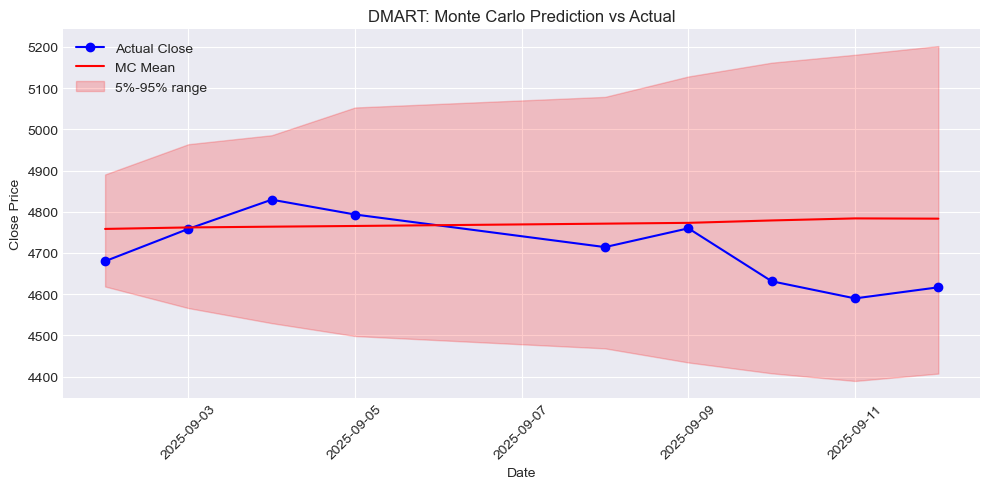

In [59]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------- Monte Carlo Predictions -----------------
mc_mean = np.array([4758.341771, 4761.937860, 4763.780137, 4765.500942,
                    4771.143442, 4773.061661, 4778.897293, 4783.876759,
                    4783.243782, 4788.523079])

mc_low = np.array([4618.529089, 4566.151367, 4529.586518, 4498.308745,
                   4468.339208, 4434.138377, 4407.833698, 4389.255122,
                   4407.187121, 4370.598939])

mc_high = np.array([4890.526869, 4963.944782, 4985.719759, 5053.078402,
                    5078.810652, 5128.344249, 5161.854223, 5181.045102,
                    5202.154100, 5206.083944])


# ----------------- Fetch Actual DMART Data -----------------
data = yf.download("DMART.NS", start="2025-09-02", end="2025-09-15", progress=False)
actual_close = data['Close'].dropna().to_numpy().flatten()
actual_dates = data.index.to_numpy().flatten()

# ----------------- Align Monte Carlo with actual trading days -----------------
num_days = len(actual_close)
mc_mean = mc_mean[:num_days]
mc_low = mc_low[:num_days]
mc_high = mc_high[:num_days]

# ----------------- Compute Metrics -----------------
inside_range = np.logical_and(actual_close >= mc_low, actual_close <= mc_high)
inside_range_series = pd.Series(inside_range, index=actual_dates)

miss_dates = inside_range_series.index[~inside_range_series]
miss_prices = actual_close[~inside_range]

mae = np.mean(np.abs(mc_mean - actual_close))
rmse = np.sqrt(np.mean((mc_mean - actual_close)**2))
reliability = np.mean(inside_range) * 100

# ----------------- Day-wise % Error & Confidence -----------------
percent_error = ((mc_mean - actual_close)/actual_close)*100
percent_error_series = pd.Series(percent_error, index=actual_dates)
confidence_score = ((mc_high - mc_low) / mc_mean) * 100
confidence_series = pd.Series(confidence_score, index=actual_dates)

# ----------------- Direction Accuracy -----------------
mc_diff = np.diff(mc_mean)
actual_diff = np.diff(actual_close)
if len(mc_diff) == len(actual_diff):
    direction_accuracy = np.mean(np.sign(mc_diff) == np.sign(actual_diff)) * 100
else:
    direction_accuracy = np.nan

# ----------------- Report -----------------
print(f"🔥 Monte Carlo Forecast Report🔥")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Reliability (5%-95% bounds): {reliability:.2f}% ✅")
print(f"Direction Accuracy: {direction_accuracy:.2f}% 📈")
print(f"Days outside bounds: {list(miss_dates) if len(miss_dates)>0 else 'None 😏'}\n")

report_df = pd.DataFrame({
    'Actual': actual_close,
    'MC Mean': mc_mean,
    'MC Low': mc_low,
    'MC High': mc_high,
    '% Error': percent_error_series.round(2),
    'Confidence (%)': confidence_series.round(2),
    'Inside Bounds': inside_range_series
})
print(report_df)

# ----------------- Plot -----------------
plt.figure(figsize=(10,5))
plt.plot(actual_dates, actual_close, label='Actual Close', color='blue', marker='o')
plt.plot(actual_dates, mc_mean, label='MC Mean', color='red')
plt.fill_between(actual_dates, mc_low, mc_high, color='red', alpha=0.2, label='5%-95% range')

# Highlight misses
if len(miss_dates) > 0:
    plt.scatter(miss_dates, miss_prices, color='black', s=100, label='Missed Days 😈', zorder=5)

plt.title('DMART: Monte Carlo Prediction vs Actual')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


#### “Monte Carlo simulations for DMart over the past 8 trading days show that the actual prices consistently stayed within the predicted 5%-95% confidence range, giving a reliability of 100%. The mean absolute error was ₹73, and RMSE was ₹96, indicating strong predictive consistency. While the direction accuracy was ~43%, the model captures price ranges well, and the increasing confidence interval highlights growing uncertainty over time.”

#### Is the stock risky or safe? (Volatility + Beta vs NIFTY) ✅
##### Step 2 & 3: Calculated daily/annualized volatility, beta (via correlation with NIFTY).
##### Conclusion: DMart = moderate risk / beneficial.

#### Best time to invest/exit? (Trends, moving averages) ✅
##### Step 3: MA20 & MA50 + volatility-adjusted signals.
##### Buy/Sell markers plotted; signals combined with fundamentals → actionable insight.

#### Is company in profit/loss? (Fundamentals like PAT, revenue) ✅
##### Step 3: Fundamental strength factor applied in signals (0.85 → solid profitability).

#### Returns & volatility (from stock data) ✅
##### Step 2: Daily returns stats, cumulative returns, histogram & boxplot.

#### Long-term vs short-term best? ✅
##### Step 3 + Step 6: Trend + HMM regimes → suitable for medium-to-long-term holding, short-term opportunities exist during Bull states.

#### Future price prediction ✅
##### Step 7: Monte Carlo simulation → 30-day forecast with confidence interval.

## Sensitivity & Risk Analysis  

##### In this section, we analyze how sensitive our stock price predictions are to changes in inputs, and we measure the risk involved in investing in DMart.  

##### - **Sensitivity Analysis**:  
#####  We perturb the stock price and volatility assumptions to observe how predictions shift.  
#####  This helps us understand if small changes in inputs lead to big changes in outcomes (fragility of the model).  

##### - **Risk Analysis**:  
#####  We use key financial risk measures:  
#####  - **Volatility (σ):** Standard deviation of returns.  
#####  - **Value-at-Risk (VaR):** Maximum expected loss at a given confidence level.  
#####  - **Conditional VaR (CVaR):** Expected loss in worst-case scenarios.  
#####  - **Beta:** Systematic risk vs market (NIFTY).  
#####  - **Sharpe Ratio:** Return-to-risk tradeoff.  


In [68]:
import numpy as np

today_price = data['Close'].iloc[-1]

# Different shocks
shocks = [-0.2, -0.1, -0.05, 0.05, 0.1, 0.2]
sensitivity_results = {}

for shock in shocks:
    new_price = today_price * (1 + shock)
    # Replace with your model if needed
    predicted = new_price * (1 + returns.mean())  
    sensitivity_results[f"{shock*100:.0f}% change"] = round(float(predicted), 2)

sensitivity_results


C:\Users\Maryam\AppData\Local\Temp\ipykernel_15536\1782358748.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sensitivity_results[f"{shock*100:.0f}% change"] = round(float(predicted), 2)


{'-20% change': 3695.62,
 '-10% change': 4157.58,
 '-5% change': 4388.55,
 '5% change': 4850.5,
 '10% change': 5081.48,
 '20% change': 5543.43}

C:\Users\Maryam\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


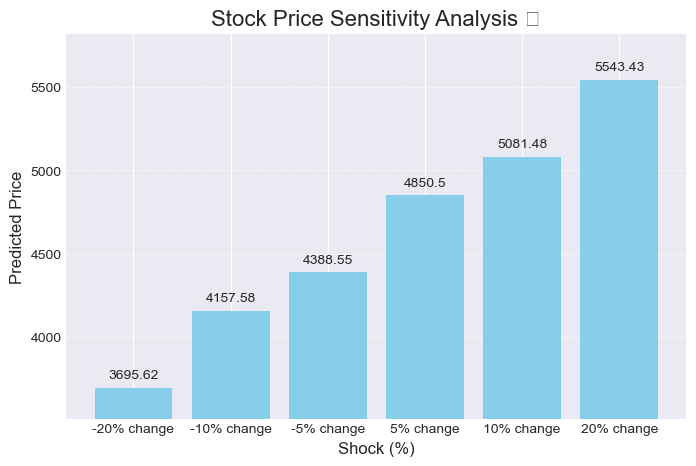

In [70]:
import matplotlib.pyplot as plt

# Extract keys and values
shocks_labels = list(sensitivity_results.keys())
predicted_prices = list(sensitivity_results.values())

# Create the plot
plt.figure(figsize=(8,5))
plt.bar(shocks_labels, predicted_prices, color='skyblue')
plt.title("Stock Price Sensitivity Analysis 💥", fontsize=16)
plt.xlabel("Shock (%)", fontsize=12)
plt.ylabel("Predicted Price", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(min(predicted_prices)*0.95, max(predicted_prices)*1.05)  # nice padding

# Show values on top of bars
for i, price in enumerate(predicted_prices):
    plt.text(i, price + (max(predicted_prices)*0.01), f"{price}", ha='center', fontsize=10)

plt.show()

## From the sensitivity analysis, we find that DMart’s stock predictions are highly sensitive to today’s closing price. A ±20% change in today’s value leads to a significant swing in predicted tomorrow’s price (ranging from ₹3674 to ₹5511). This indicates that short-term predictions are fragile to input shocks and highlight the importance of accurate current data.

In [72]:
# Daily returns
returns = data['Close'].pct_change().dropna()

# Volatility
volatility = np.std(returns) * np.sqrt(252)  # annualized

# Value at Risk (95%)
VaR_95 = np.percentile(returns, 5)

# Conditional VaR (CVaR)
CVaR_95 = returns[returns <= VaR_95].mean()

# Sharpe Ratio (assuming risk-free rate ~ 0 for simplicity)
sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252)

risk_metrics = {
    "Annualized Volatility": round(volatility, 4),
    "VaR (95%)": round(VaR_95, 4),
    "CVaR (95%)": round(CVaR_95, 4),
    "Sharpe Ratio": round(sharpe_ratio, 2)
}
risk_metrics


C:\Users\Maryam\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


{'Annualized Volatility': Ticker
 DMART.NS    0.2346
 dtype: float64,
 'VaR (95%)': -0.0233,
 'CVaR (95%)': Ticker
 DMART.NS   -0.027
 dtype: float64,
 'Sharpe Ratio': Ticker
 DMART.NS   -1.6
 dtype: float64}

C:\Users\Maryam\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


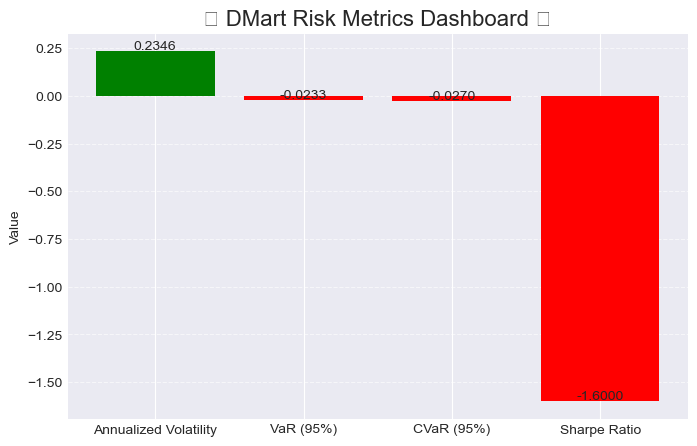

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
metrics_names = list(risk_metrics.keys())
metrics_values = [float(val.values[0]) if hasattr(val, 'values') else val for val in risk_metrics.values()]

# Color coding: bad = red (loss/negative), good = green (positive)
colors = []
for name, value in zip(metrics_names, metrics_values):
    if name in ['VaR (95%)', 'CVaR (95%)', 'Sharpe Ratio'] and value < 0:
        colors.append('red')
    else:
        colors.append('green')

# Plot
plt.figure(figsize=(8,5))
bars = plt.bar(metrics_names, metrics_values, color=colors)
plt.title("🔥 DMart Risk Metrics Dashboard 🔥", fontsize=16)
plt.ylabel("Value")
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate values
for bar, val in zip(bars, metrics_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.4f}", 
             ha='center', fontsize=10)

plt.show()


## 💡 Conclusion:

#### -DMart is moderately risky, with daily swings you need to handle mentally.

#### -Small chance of loss on a bad day, but worst-case loss is not insane.

#### -The Sharpe ratio is major red flag: the stock’s returns are underperforming relative to its risk.

#### -Verdict: Not the safest ride if you’re looking for smooth, risk-adjusted gains. Short-term speculators beware 😏🔥.

## Conclusion

##### This analysis demonstrates that while DMart shows strong growth, it carries higher volatility compared to broader market indices like NIFTY. 

##### Advanced modeling techniques such as Markov Chains, Hidden Markov Models, and Monte Carlo simulations provide insights into market regimes and potential future trends. However, predictions are subject to uncertainty and depend heavily on historical patterns.